# 01_10 — Add xGen CDKN2A / p16 / p14ARF counts to the PacBio donors that have a pulldown

In [ ]:
print("Hello World")

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import os, gc
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.io import mmread
gc.enable()

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"
CDKN2A_DIR = f"./../pacbio_xgen/cdkn2a_distinct_umi"
SEURAT_DIR = f"./../pacbio_xgen/pigeon/seurat_pbids"

# donors with an xGen CDKN2A pulldown -> their pulldown tissue id
DONOR_TO_PULLDOWN = {"TSP21": "T70", "TSP25": "T71", "TSP27": "T72", "TSP33": "T73"}
KEEP_DONORS = list(DONOR_TO_PULLDOWN)

STEM = "all_samples_pacbio_recollapsed_raw_counts_{level}_bc_anndata"

# objects to annotate: (input-stem-suffix, levels).
#   preprocessed    -> genes / pbids / ensemblids / ensemblids_annotatedonly
#   with_isofrac    -> pbids / ensemblids / ensemblids_annotatedonly only (no gene-level isofrac object)
VARIANTS = [
    ("_preprocessed",              ["genes", "pbids", "ensemblids", "ensemblids_annotatedonly"]),
    ("_preprocessed_with_isofrac", ["pbids", "ensemblids", "ensemblids_annotatedonly"]),
]

# (in_path, out_path, label) for every object we process
TARGETS = []
for suffix, levels in VARIANTS:
    for level in levels:
        stem = STEM.format(level=level) + suffix
        TARGETS.append((
            f"{H5AD_DIR}/{stem}.h5ad",
            f"{H5AD_DIR}/{stem}_xgen_cdkn2a.h5ad",
            f"{level}{suffix}",
        ))
for _in, _out, _lab in TARGETS:
    print(f"{_lab:35s} {os.path.basename(_in)}  ->  {os.path.basename(_out)}")

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


genes_preprocessed                  all_samples_pacbio_recollapsed_raw_counts_genes_bc_anndata_preprocessed.h5ad  ->  all_samples_pacbio_recollapsed_raw_counts_genes_bc_anndata_preprocessed_xgen_cdkn2a.h5ad
pbids_preprocessed                  all_samples_pacbio_recollapsed_raw_counts_pbids_bc_anndata_preprocessed.h5ad  ->  all_samples_pacbio_recollapsed_raw_counts_pbids_bc_anndata_preprocessed_xgen_cdkn2a.h5ad
ensemblids_preprocessed             all_samples_pacbio_recollapsed_raw_counts_ensemblids_bc_anndata_preprocessed.h5ad  ->  all_samples_pacbio_recollapsed_raw_counts_ensemblids_bc_anndata_preprocessed_xgen_cdkn2a.h5ad
ensemblids_annotatedonly_preprocessed all_samples_pacbio_recollapsed_raw_counts_ensemblids_annotatedonly_bc_anndata_preprocessed.h5ad  ->  all_samples_pacbio_recollapsed_raw_counts_ensemblids_annotatedonly_bc_anndata_preprocessed_xgen_cdkn2a.h5ad
pbids_preprocessed_with_isofrac     all_samples_pacbio_recollapsed_raw_counts_pbids_bc_anndata_preprocessed_with_isofrac.h

## Build the xGen CDKN2A table (raw + calibrated)

For each pulldown, build a per-`(donor, bare barcode)` table with both count flavours:

**Raw pigeon matrix counts** (`*_raw`):
- **CDKN2A** — sum of the gene-level `genes_seurat` columns whose gene symbol is `CDKN2A` (exact, excludes `CDKN2A-DT`).
- **p16 / p14ARF / other_CDKN2A** — sum of the `isoforms_seurat` isoform columns assigned to each class by the pigeon `associated_transcript` map in `{tissue}_cdkn2a_isoform_classification.csv`.
- **`xgen_cdkn2a_raw_pos` / `xgen_cdkn2a_raw_status`** — derived here from the raw per-class counts (positive = any CDKN2A signal > 0; status = p16+ / p14ARF+ / Both / other_CDKN2A+ / CDKN2A-), mirroring the calibrated categories.

**Calibrated distinct-UMI counts** (`*_umi`, + `xgen_cdkn2a_umi_cutoff` / `xgen_cdkn2a_umi_pos` / `xgen_cdkn2a_umi_status`) — from `{tissue}_cdkn2a_cells.csv`.

Barcodes (`{bc}-1`) are in PacBio (reverse-complement) orientation and unique within a pulldown.

In [2]:
def load_seurat(mtx_dir):
    """Return (cells x features CSR, genes DataFrame[pb_id_gene, gene_name], bare-barcode array)."""
    X = mmread(f"{mtx_dir}/matrix.mtx").T.tocsr()   # mmread is features x cells -> transpose
    genes = pd.read_csv(f"{mtx_dir}/genes.tsv", sep="\t", header=None,
                        names=["pb_id_gene", "gene_name"])
    bc = pd.read_csv(f"{mtx_dir}/barcodes.tsv", header=None, names=["barcode"])["barcode"].astype(str)
    bare = np.array([b.split("-1")[0] for b in bc])   # '{bc}-1' -> '{bc}'
    return X, genes, bare


def colsum_by_mask(X, mask):
    return np.asarray(X[:, mask].sum(axis=1)).ravel() if mask.any() else np.zeros(X.shape[0])


def cdkn2a_status(cdkn2a, p16, p14arf, other):
    """Vectorized p16+ / p14ARF+ / Both / other_CDKN2A+ / CDKN2A- status from per-class counts.
    Positive = any CDKN2A signal (gene-level count or any class > 0); mirrors the calibrated
    `status` categories. Returns (pos_bool_array, status_str_array)."""
    cdkn2a, p16, p14arf, other = (np.asarray(x) for x in (cdkn2a, p16, p14arf, other))
    pos = (cdkn2a > 0) | (p16 > 0) | (p14arf > 0) | (other > 0)
    has16, has14 = p16 > 0, p14arf > 0
    status = np.where(has16 & has14, "Both",
             np.where(has16, "p16+",
             np.where(has14, "p14ARF+",
             np.where(pos, "other_CDKN2A+", "CDKN2A-"))))
    return pos, status.astype(object)


# calibrated distinct-UMI CSV column -> obs column name
CALIB_RENAME = {
    "cdkn2a_distinct_umi":       "xgen_cdkn2a_umi",
    "p16_distinct_umi":          "xgen_p16_umi",
    "p14ARF_distinct_umi":       "xgen_p14ARF_umi",
    "other_cdkn2a_distinct_umi": "xgen_other_cdkn2a_umi",
    "cutoff":                    "xgen_cdkn2a_umi_cutoff",
    "cdkn2a_pos":                "xgen_cdkn2a_umi_pos",
    "status":                    "xgen_cdkn2a_umi_status",
}

parts = []
for donor, tissue in DONOR_TO_PULLDOWN.items():
    sdir = f"{SEURAT_DIR}/{tissue}"

    # --- raw: gene-level CDKN2A (exact symbol, excludes CDKN2A-DT) ---
    Xg, gg, bare_g = load_seurat(f"{sdir}/genes_seurat")
    gmask = (gg["gene_name"].astype(str) == "CDKN2A").to_numpy()
    gene_df = pd.DataFrame({"barcode": bare_g,
                            "xgen_cdkn2a_raw": colsum_by_mask(Xg, gmask).astype(int)})

    # --- raw: isoform-level p16 / p14ARF / other_CDKN2A via the pigeon associated_transcript class map ---
    Xi, gi, bare_i = load_seurat(f"{sdir}/isoforms_seurat")
    pb_iso = np.array([str(v).split(":")[0] for v in gi["pb_id_gene"]])   # 'PB.X.Y:GENE' -> 'PB.X.Y'
    cls = pd.read_csv(f"{CDKN2A_DIR}/{tissue}_cdkn2a_isoform_classification.csv")
    class_map = dict(zip(cls["pb_isoform"].astype(str), cls["class"].astype(str)))
    iso_class = np.array([class_map.get(p, "") for p in pb_iso])
    iso_df = pd.DataFrame({"barcode": bare_i})
    for cname, dst in [("p16", "xgen_p16_raw"),
                       ("p14ARF", "xgen_p14ARF_raw"),
                       ("other_CDKN2A", "xgen_other_cdkn2a_raw")]:
        iso_df[dst] = colsum_by_mask(Xi, iso_class == cname).astype(int)

    # --- calibrated distinct-UMI calls ---
    cu = pd.read_csv(f"{CDKN2A_DIR}/{tissue}_cdkn2a_cells.csv").rename(columns=CALIB_RENAME)
    cu = cu[["barcode"] + list(CALIB_RENAME.values())]

    # merge raw (genes + isoforms) and calibrated on the bare barcode
    d = gene_df.merge(iso_df, on="barcode", how="outer").merge(cu, on="barcode", how="outer")
    d["donor"] = donor
    parts.append(d)
    print(f"[{tissue}/{donor}] cells: genes {len(bare_g):,} / isoforms {len(bare_i):,} / calib {len(cu):,} | "
          f"CDKN2A raw>0 {(gene_df['xgen_cdkn2a_raw'] > 0).sum():,} | "
          f"CDKN2A+ (calib) {int(cu['xgen_cdkn2a_umi_pos'].sum()):,}")

xgen = pd.concat(parts, ignore_index=True)

# --- raw-matrix status/pos (parallel to the calibrated *_umi_status/pos), from the raw per-class counts ---
_raw_pos, _raw_status = cdkn2a_status(xgen["xgen_cdkn2a_raw"], xgen["xgen_p16_raw"],
                                      xgen["xgen_p14ARF_raw"], xgen["xgen_other_cdkn2a_raw"])
xgen["xgen_cdkn2a_raw_pos"] = _raw_pos
xgen["xgen_cdkn2a_raw_status"] = _raw_status

xgen["key"] = xgen["donor"].astype(str) + "|" + xgen["barcode"].astype(str)
assert xgen["key"].is_unique, "duplicate (donor, barcode) keys across the pulldown tables"
xgen = xgen.set_index("key")
print(f"\nxGen pulldown cells total: {len(xgen):,}")
print("raw status counts:\n", xgen["xgen_cdkn2a_raw_status"].value_counts())

[T70/TSP21] cells: genes 6,851 / isoforms 6,851 / calib 6,851 | CDKN2A raw>0 3,036 | CDKN2A+ (calib) 2,386
[T71/TSP25] cells: genes 9,251 / isoforms 9,251 / calib 9,251 | CDKN2A raw>0 7,548 | CDKN2A+ (calib) 5,961
[T72/TSP27] cells: genes 11,081 / isoforms 11,081 / calib 11,081 | CDKN2A raw>0 3,229 | CDKN2A+ (calib) 2,354
[T73/TSP33] cells: genes 5,019 / isoforms 5,019 / calib 5,019 | CDKN2A raw>0 2,506 | CDKN2A+ (calib) 1,534

xGen pulldown cells total: 32,202
raw status counts:
 xgen_cdkn2a_raw_status
CDKN2A-          15883
Both              9692
other_CDKN2A+     3779
p16+              2760
p14ARF+             88
Name: count, dtype: int64


[T71/TSP25] cells: genes 9,251 / isoforms 9,251 / calib 9,251 | CDKN2A raw>0 7,548 | CDKN2A+ (calib) 5,961


[T72/TSP27] cells: genes 11,081 / isoforms 11,081 / calib 11,081 | CDKN2A raw>0 3,229 | CDKN2A+ (calib) 2,354
[T73/TSP33] cells: genes 5,019 / isoforms 5,019 / calib 5,019 | CDKN2A raw>0 2,506 | CDKN2A+ (calib) 1,534

xGen pulldown cells total: 32,202
raw status counts:
 xgen_cdkn2a_raw_status
CDKN2A-          15883
Both              9692
other_CDKN2A+     3779
p16+              2760
p14ARF+             88
Name: count, dtype: int64


## Subset each level to the four donors and attach the xGen columns

In [3]:
# xGen columns transferred onto the PacBio obs, grouped by fill/dtype
XGEN_NUM_COLS = [
    "xgen_cdkn2a_raw", "xgen_p16_raw", "xgen_p14ARF_raw", "xgen_other_cdkn2a_raw",   # raw pigeon matrix
    "xgen_cdkn2a_umi", "xgen_p16_umi", "xgen_p14ARF_umi", "xgen_other_cdkn2a_umi",   # calibrated distinct-UMI
    "xgen_cdkn2a_umi_cutoff",
]
XGEN_BOOL_COLS = ["xgen_cdkn2a_raw_pos", "xgen_cdkn2a_umi_pos"]
XGEN_STATUS_COLS = ["xgen_cdkn2a_raw_status", "xgen_cdkn2a_umi_status"]


def add_xgen(in_path, out_path, label, save=True):
    adata = sc.read_h5ad(in_path)
    n0 = adata.n_obs

    # subset to the four donors that have an xGen CDKN2A pulldown
    adata = adata[adata.obs["donor"].isin(KEEP_DONORS)].copy()
    # RECOMPUTE QC: this subset drops CELLS, so var stats inherited from
    # 01_08/01_09 still count the full atlas. Without this, a feature can
    # report n_cells_by_counts larger than the object's own n_obs.
    sc.pp.calculate_qc_metrics(adata, inplace=True)

    # per-cell lookup key: (donor, bare PacBio-orientation barcode). obs_names are '{bc}-1_T##'.
    bare_bc = np.array([str(x).split("-1")[0] for x in adata.obs_names])
    keys = adata.obs["donor"].astype(str).values + "|" + bare_bc
    idx = xgen.reindex(keys)

    # 'barcode' is NaN for cells whose barcode is not among the pulldown's called cells
    matched = idx["barcode"].notna().to_numpy()
    adata.obs["xgen_matched"] = matched

    for dst in XGEN_NUM_COLS:
        col = pd.Series(idx[dst].to_numpy(), index=adata.obs_names)
        adata.obs[dst] = pd.to_numeric(col, errors="coerce").fillna(0).astype(int)
    for dst in XGEN_BOOL_COLS:
        adata.obs[dst] = pd.Series(idx[dst].to_numpy(), index=adata.obs_names).fillna(False).astype(bool)
    for dst in XGEN_STATUS_COLS:
        adata.obs[dst] = (
            pd.Series(idx[dst].to_numpy(), index=adata.obs_names)
            .fillna("not_in_pulldown").astype("category")
        )

    if save:
        adata.write_h5ad(out_path)

    rec = {
        "object": label,
        "cells_in": n0,
        "cells_out": adata.n_obs,
        "xgen_matched": int(matched.sum()),
        "cdkn2a_raw_pos": int(adata.obs["xgen_cdkn2a_raw_pos"].sum()),
        "cdkn2a_umi_pos": int(adata.obs["xgen_cdkn2a_umi_pos"].sum()),
        "out_path": os.path.basename(out_path),
    }
    print(f"[{label}] cells {n0:,} -> {adata.n_obs:,} (4 xGen donors) | "
          f"xGen-matched {int(matched.sum()):,} | CDKN2A raw+ {rec['cdkn2a_raw_pos']:,} | "
          f"CDKN2A+ calib {rec['cdkn2a_umi_pos']:,} | saved {out_path}")
    del adata
    gc.collect()
    return rec

In [4]:
records = [add_xgen(in_path, out_path, label) for in_path, out_path, label in TARGETS]
summary = pd.DataFrame(records)
summary

/tmp/ipykernel_9443/3412596961.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[dst] = pd.Series(idx[dst].to_numpy(), index=adata.obs_names).fillna(False).astype(bool)
/tmp/ipykernel_9443/3412596961.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[dst] = pd.Series(idx[dst].to_numpy(), index=adata.obs_names).fillna(False).astype(bool)


[genes_preprocessed] cells 203,311 -> 155,117 (4 xGen donors) | xGen-matched 8,954 | CDKN2A raw+ 4,069 | CDKN2A+ calib 3,194 | saved ./../pacbio/h5ads/all_samples_pacbio_recollapsed_raw_counts_genes_bc_anndata_preprocessed_xgen_cdkn2a.h5ad


/tmp/ipykernel_9443/3412596961.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[dst] = pd.Series(idx[dst].to_numpy(), index=adata.obs_names).fillna(False).astype(bool)
/tmp/ipykernel_9443/3412596961.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[dst] = pd.Series(idx[dst].to_numpy(), index=adata.obs_names).fillna(False).astype(bool)


[molecules_preprocessed] cells 203,311 -> 155,117 (4 xGen donors) | xGen-matched 8,954 | CDKN2A raw+ 4,069 | CDKN2A+ calib 3,194 | saved ./../pacbio/h5ads/all_samples_pacbio_recollapsed_raw_counts_pbids_bc_anndata_preprocessed_xgen_cdkn2a.h5ad


/tmp/ipykernel_9443/3412596961.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[dst] = pd.Series(idx[dst].to_numpy(), index=adata.obs_names).fillna(False).astype(bool)
/tmp/ipykernel_9443/3412596961.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[dst] = pd.Series(idx[dst].to_numpy(), index=adata.obs_names).fillna(False).astype(bool)


...

/tmp/ipykernel_9443/3412596961.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[dst] = pd.Series(idx[dst].to_numpy(), index=adata.obs_names).fillna(False).astype(bool)
/tmp/ipykernel_9443/3412596961.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[dst] = pd.Series(idx[dst].to_numpy(), index=adata.obs_names).fillna(False).astype(bool)


[transcripts_preprocessed_with_isofrac] cells 203,311 -> 155,117 (4 xGen donors) | xGen-matched 8,954 | CDKN2A raw+ 4,069 | CDKN2A+ calib 3,194 | saved ./../pacbio/h5ads/all_samples_pacbio_recollapsed_raw_counts_ensemblids_bc_anndata_preprocessed_with_isofrac_xgen_cdkn2a.h5ad


/tmp/ipykernel_9443/3412596961.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[dst] = pd.Series(idx[dst].to_numpy(), index=adata.obs_names).fillna(False).astype(bool)
/tmp/ipykernel_9443/3412596961.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[dst] = pd.Series(idx[dst].to_numpy(), index=adata.obs_names).fillna(False).astype(bool)


[isoforms_preprocessed_with_isofrac] cells 203,311 -> 155,117 (4 xGen donors) | xGen-matched 8,954 | CDKN2A raw+ 4,069 | CDKN2A+ calib 3,194 | saved ./../pacbio/h5ads/all_samples_pacbio_recollapsed_raw_counts_ensemblids_annotatedonly_bc_anndata_preprocessed_with_isofrac_xgen_cdkn2a.h5ad


,object,cells_in,cells_out,xgen_matched,cdkn2a_raw_pos,cdkn2a_umi_pos,out_path
0,genes_preprocessed,203311,155117,8954,4069,3194,all_samples_pacbio_recollapsed_raw_counts_gene...
1,molecules_preprocessed,203311,155117,8954,4069,3194,all_samples_pacbio_recollapsed_raw_counts_mole...
2,transcripts_preprocessed,203311,155117,8954,4069,3194,all_samples_pacbio_recollapsed_raw_counts_tran...
3,isoforms_preprocessed,203311,155117,8954,4069,3194,all_samples_pacbio_recollapsed_raw_counts_isof...
4,molecules_preprocessed_with_isofrac,203311,155117,8954,4069,3194,all_samples_pacbio_recollapsed_raw_counts_mole...
5,transcripts_preprocessed_with_isofrac,203311,155117,8954,4069,3194,all_samples_pacbio_recollapsed_raw_counts_tran...
6,isoforms_preprocessed_with_isofrac,203311,155117,8954,4069,3194,all_samples_pacbio_recollapsed_raw_counts_isof...


## Read back the xGen-CDKN2A object and plot CDKN2A+ proportion per tissue (raw)

Loaded 155117 cells | donors: ['TSP21', 'TSP25', 'TSP27', 'TSP33'] | CDKN2A+ (raw): 4069


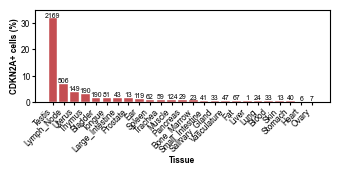

                 n_cells  n_pos  pct_pos
tissue                                  
Testis              6829   2169   31.762
Lymph_Node          7220    506    7.008
Uterus              3789    149    3.932
Thymus              5786    190    3.284
Bladder            11003    190    1.727
Tongue              4785     81    1.693
Large_Intestine     2799     43    1.536
Prostate             879     13    1.479
Ear                 8643    119    1.377
Spleen              6128     62    1.012
Trachea             5950     59    0.992
Muscle             15639    124    0.793
Pancreas            3714     29    0.781
Bone_Marrow         3323     23    0.692
Small_Intestine     6397     41    0.641
Salivary_Gland      5446     33    0.606
Vasculature         8154     47    0.576
Fat                12702     67    0.527
Liver                198      1    0.505
Lung                5075     24    0.473
Blood               7915     33    0.417
Skin                3528     13    0.368
Stomach         

In [5]:
# Read back an xGen-CDKN2A object (genes level; cells/tissue/status are identical across levels)
# and plot the proportion of CDKN2A+ cells per tissue using the raw pigeon-matrix flag
# (xgen_cdkn2a_raw_pos). The object is already subset to the 4 pulldown donors (TSP21/25/27/33).
import matplotlib, matplotlib.pyplot as plt

_stem = "all_samples_pacbio_recollapsed_raw_counts_genes_bc_anndata_preprocessed"
adata_xg = sc.read_h5ad(f"{H5AD_DIR}/{_stem}_xgen_cdkn2a.h5ad")
print(f"Loaded {adata_xg.n_obs} cells | donors: {sorted(adata_xg.obs['donor'].unique())} | "
      f"CDKN2A+ (raw): {int(adata_xg.obs['xgen_cdkn2a_raw_pos'].sum())}")

# proportion of CDKN2A+ cells (raw flag) per tissue
prop = (adata_xg.obs.groupby("tissue", observed=True)["xgen_cdkn2a_raw_pos"]
        .agg(n_cells="size", n_pos="sum"))
prop = prop[prop["n_cells"] > 0].copy()
prop["pct_pos"] = 100 * prop["n_pos"] / prop["n_cells"]
prop = prop.sort_values("pct_pos", ascending=False)

# preferred plot formatting
TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0   # pass explicitly: ax.set_title(..., pad=PANEL_TITLE_PAD)
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Arial"] + matplotlib.rcParams["font.sans-serif"]
plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "legend.fontsize": 6, "legend.title_fontsize": 6,
    "legend.labelspacing": 0.1, "legend.borderpad": 0.3, "legend.handletextpad": 0.2,
    "axes.labelweight": "bold", "axes.titleweight": "bold", "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN, "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD, "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
})
fig, ax = plt.subplots(figsize=(3.8, 1.2))
ax.bar(range(len(prop)), prop["pct_pos"].values, color="#c44e52", edgecolor="white", linewidth=0.3)
ax.set_xticks(range(len(prop)))
ax.set_xticklabels(prop.index, rotation=45, ha = "right")
ax.set_ylabel("CDKN2A+ cells (%)")
ax.set_xlabel("Tissue")
ax.set_ylim(0, 35)
# ax.set_title("Proportion of CDKN2A+ cells per tissue (xGen raw)", pad=3.0)
for i, n in enumerate(prop["n_pos"].values):          # label each bar with the CDKN2A+ cell count
    ax.text(i, prop["pct_pos"].values[i], str(int(n)), ha="center", va="bottom", fontsize=5)
# plt.tight_layout()
plt.savefig(figpath("01_10_cdkn2a_pos_proportion_per_tissue_xgen_raw.pdf"), bbox_inches="tight", dpi=300)
plt.show()
print(prop.round(3).to_string())

## Senescent (CDKN2A+ raw) percent per tube_id, then mean per tissue with error bars

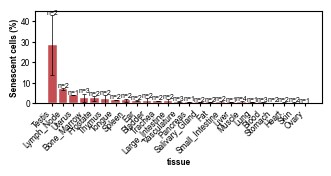

Senescent % per tube_id:
                  tissue  donor  n_cells  pct_sen
tube_id                                          
T45               Testis  TSP25     4201   42.871
T16               Testis  TSP33     2628   14.003
T34           Lymph_Node  TSP27     5123    7.242
T65          Bone_Marrow  TSP27      130    6.923
T47           Lymph_Node  TSP25     2097    6.438
T31               Uterus  TSP21     3789    3.932
T17               Thymus  TSP33     4790    3.904
T21             Prostate  TSP33       56    3.571
T39              Bladder  TSP27     8116    2.341
T48               Spleen  TSP25     1146    2.269
T40      Large_Intestine  TSP27     2165    1.986
T44               Tongue  TSP27     4572    1.706
T57               Muscle  TSP27     6899    1.681
T3                   Ear  TSP33     5863    1.467
T13               Tongue  TSP33      213    1.408
T22          Vasculature  TSP33       73    1.370
T50             Prostate  TSP25      823    1.337
T56              Trachea 

In [6]:
# Senescent % per tube_id (per-sample tissue ID), then mean +/- SEM across tube_ids within each
# tissue name. Senescent = CDKN2A+ from the raw pigeon-matrix flag (xgen_cdkn2a_raw_pos).
# Reuses adata_xg loaded in the cell above (already subset to the 4 pulldown donors).

# (1) senescent percent per tube_id
per_tube = (adata_xg.obs.groupby("tube_id", observed=True)
            .agg(tissue=("tissue", "first"),
                 donor=("donor", "first"),
                 n_cells=("xgen_cdkn2a_raw_pos", "size"),
                 pct_sen=("xgen_cdkn2a_raw_pos", lambda x: 100 * x.mean())))
per_tube = per_tube[per_tube["n_cells"] > 0]

# (2) mean +/- SEM of the per-tube senescent % within each tissue
tis = (per_tube.groupby("tissue", observed=True)["pct_sen"]
       .agg(mean="mean", sem="sem", n_tubes="size")
       .sort_values("mean", ascending=False))

# (3) bar of per-tissue mean with SEM error bars (preferred formatting persists from the cell above)
fig, ax = plt.subplots(figsize=(3.7, 1.2))
ax.bar(range(len(tis)), tis["mean"].values, yerr=tis["sem"].fillna(0).values,
       color="#c44e52", edgecolor="white", linewidth=0.3,
       error_kw=dict(elinewidth=0.5, capsize=1.5, capthick=0.5))
ax.set_xticks(range(len(tis)))
ax.set_xticklabels(tis.index, rotation=45, ha="right")
ax.set_ylabel("Senescent cells (%)")
ax.set_xlabel("tissue")
# label each bar with the number of tube_ids (samples) averaged
for i, n in enumerate(tis["n_tubes"].values):
    y = tis["mean"].values[i] + tis["sem"].fillna(0).values[i]
    ax.text(i, y, f"n={int(n)}", ha="center", va="bottom", fontsize=5)
plt.savefig(figpath("01_10_senescent_pct_per_tissue_mean_sem_xgen_raw.pdf"), bbox_inches="tight", dpi=300)
plt.show()

print("Senescent % per tube_id:")
print(per_tube.sort_values("pct_sen", ascending=False).round(3).to_string())
print("\nPer-tissue mean +/- SEM (across tube_ids):")
print(tis.round(3).to_string())

In [14]:
# === CDKN2A per-cell counts for the DEPOSITED atlas cells -> TWO CSVs ===
#
#   xgen_cdkn2a_per_cell_pigeon_raw.csv     pigeon Seurat matrix counts
#   xgen_cdkn2a_per_cell_distinct_umi.csv   distinct-UMI (XM tag) counts
#
# ONE ROW PER CELL of the preprocessed long-read object, restricted to the four
# donors carrying an xGen pulldown (the other donors have no CDKN2A capture, so
# no row would carry a measurement). `cell_id` is the atlas obs_name, so these
# join straight onto the deposited h5ads with no barcode handling:
#
#     df = pd.read_csv(...).set_index("cell_id")
#     adata.obs = adata.obs.join(df)
#
# Values are transferred exactly as the h5ad obs columns are built above, by
# reindexing the pulldown table onto (donor, bare barcode) and filling misses:
# counts 0, flags False, status "not_in_pulldown". A pulldown barcode matching
# several atlas cells (a 10x barcode is unique only within a run) supplies the
# same values to each, which is the same behaviour as the obs transfer.
# `xgen_matched` separates a measured zero from a cell the capture never saw.
#
# These files carry the CDKN2A calls for the deposit: the *_xgen_cdkn2a h5ads
# are not being deposited, so this is where a user gets senescence status.
#
# COLUMNS. The 14 annotated CDKN2A transcripts plus one `novel` bin. PB ids are
# NOT used as columns: the four pulldowns were collapsed independently and never
# globally re-collapsed, so their PB namespaces are DISJOINT (2,417 ids, zero
# shared by all four) and a PB.X.Y column would mean a different structure in
# each donor. Keying on `associated_transcript` fixes that because the annotated
# set IS shared. 93-98% of CDKN2A isoforms are novel, matched no annotated
# transcript, and are therefore all classed other_CDKN2A; they collapse into
# `novel` with no loss of class information.
#
# COUNT SEMANTICS. isoseq groupdedup groups reads by cell barcode, UMI AND
# insert structure, so one deeply sequenced UMI is emitted as several
# "molecules": for CDKN2A here the matrix count runs ~14.6x the distinct-UMI
# count, depth-dependently. distinct_umi is the molecule count and is what to
# use quantitatively; pigeon_raw is what the h5ad `xgen_*_raw` columns and the
# published status calls were computed from, so it reproduces the figures.
#
# EXACTNESS. Each annotated transcript is backed by 1.7-1.9 PB isoforms (max 4),
# so a column sums several per-isoform values. Exact for pigeon_raw. For
# distinct_umi it can OVERCOUNT, since two PB isoforms of one transcript may
# share a UMI the sum counts twice. The class_* columns alongside are the
# properly deduplicated per-cell totals -- use those for an exact p16 / p14ARF /
# other total rather than summing the transcript columns.

CSV_DIR = "./../csvs"
OUT_RAW = f"{CSV_DIR}/xgen_cdkn2a_per_cell_pigeon_raw.csv"
OUT_UMI = f"{CSV_DIR}/xgen_cdkn2a_per_cell_distinct_umi.csv"
NOVEL = "novel"

ENSTS = sorted({t for _t in DONOR_TO_PULLDOWN.values()
                for t in pd.read_csv(f"{CDKN2A_DIR}/{_t}_cdkn2a_isoform_classification.csv")
                            ["associated_transcript"].astype(str).unique()
                if t != NOVEL})
FEATS = ENSTS + [NOVEL]
print(f"feature columns: {len(ENSTS)} annotated transcripts + '{NOVEL}'")

# ---- per-pulldown-cell feature tables, keyed on donor|barcode ----
raw_parts, umi_parts = [], []
for donor, tissue in DONOR_TO_PULLDOWN.items():
    cls = pd.read_csv(f"{CDKN2A_DIR}/{tissue}_cdkn2a_isoform_classification.csv")
    feat_of = {str(p): (str(a) if str(a) != NOVEL else NOVEL)
               for p, a in zip(cls["pb_isoform"], cls["associated_transcript"])}

    Xi, gi, bare_i = load_seurat(f"{SEURAT_DIR}/{tissue}/isoforms_seurat")
    key_col = np.array([feat_of.get(str(v).split(":")[0], "") for v in gi["pb_id_gene"]])
    r = pd.DataFrame({f: colsum_by_mask(Xi, key_col == f).astype(int) for f in FEATS},
                     index=donor + "|" + pd.Index(bare_i))
    raw_parts.append(r)
    del Xi, gi
    gc.collect()

    wide = pd.read_csv(f"{CDKN2A_DIR}/{tissue}_cdkn2a_isoform_distinct_umi.csv")
    pbcols = [c for c in wide.columns if c != "barcode"]
    grp = pd.Series({c: feat_of.get(str(c), "") for c in pbcols})
    # .to_numpy() is REQUIRED: a Series carries wide's RangeIndex, and passing
    # index= to the constructor makes pandas ALIGN rather than assign
    # positionally, silently producing an all-NaN (-> all-zero) table.
    u = pd.DataFrame({f: (wide[grp.index[grp == f].tolist()].sum(axis=1).to_numpy().astype(int)
                          if (grp == f).any() else np.zeros(len(wide), dtype=int))
                      for f in FEATS},
                     index=donor + "|" + pd.Index(wide["barcode"].astype(str)))
    umi_parts.append(u)
    print(f"[{tissue}/{donor}] {len(r):,} pulldown cells | annotated transcripts present: "
          f"{sum(1 for f in ENSTS if (key_col == f).any())}/{len(ENSTS)}")

raw_feat = pd.concat(raw_parts)
umi_feat = pd.concat(umi_parts)

# ---- the deposited object's cells define the rows ----
_a = sc.read_h5ad(f"{H5AD_DIR}/{STEM.format(level='pbids')}_preprocessed.h5ad", backed="r")
_obs = _a.obs[["donor", "tissue", "tube_id"]].copy()
_obs.index = _a.obs_names
_a.file.close()
del _a
gc.collect()

_obs = _obs[_obs["donor"].astype(str).isin(KEEP_DONORS)].copy()
_obs["barcode"] = [str(x).split("-1")[0] for x in _obs.index]
_keys = _obs["donor"].astype(str).values + "|" + _obs["barcode"].values
print(f"\ndeposited object: {len(_obs):,} cells across the {len(KEEP_DONORS)} pulldown donors")

CLASSCOLS = {
    "pigeon_raw":   {"cdkn2a_total": "xgen_cdkn2a_raw", "class_p16": "xgen_p16_raw",
                     "class_p14ARF": "xgen_p14ARF_raw", "class_other_CDKN2A": "xgen_other_cdkn2a_raw",
                     "cdkn2a_pos": "xgen_cdkn2a_raw_pos", "cdkn2a_status": "xgen_cdkn2a_raw_status"},
    "distinct_umi": {"cdkn2a_total": "xgen_cdkn2a_umi", "class_p16": "xgen_p16_umi",
                     "class_p14ARF": "xgen_p14ARF_umi", "class_other_CDKN2A": "xgen_other_cdkn2a_umi",
                     "cdkn2a_pos": "xgen_cdkn2a_umi_pos", "cdkn2a_status": "xgen_cdkn2a_umi_status",
                     "umi_cutoff": "xgen_cdkn2a_umi_cutoff"},
}
BOOLS = {"cdkn2a_pos"}
STATUS = {"cdkn2a_status"}

_matched = xgen.reindex(_keys)["barcode"].notna().to_numpy()
print(f"xGen-matched: {_matched.sum():,} of {len(_obs):,}")

outs = {}
for nm, feat in (("pigeon_raw", raw_feat), ("distinct_umi", umi_feat)):
    df = _obs[["donor", "tissue", "tube_id", "barcode"]].copy()
    fr = feat.reindex(_keys)                                  # fill exactly as the obs transfer does
    for f in FEATS:
        df[f] = (pd.Series(pd.to_numeric(fr[f].to_numpy(), errors="coerce"), index=df.index)
                 .fillna(0).astype(int))
    idx = xgen.reindex(_keys)
    for dst, src in CLASSCOLS[nm].items():
        col = pd.Series(idx[src].to_numpy(), index=df.index)
        if dst in BOOLS:
            df[dst] = col.fillna(False).astype(bool)
        elif dst in STATUS:
            df[dst] = col.fillna("not_in_pulldown").astype(str)
        else:
            df[dst] = pd.to_numeric(col, errors="coerce").fillna(0).astype(int)
    df["xgen_matched"] = _matched
    outs[nm] = df

# ---- checks ----
for nm, df in outs.items():
    assert len(df) == len(_obs), f"{nm}: {len(df):,} rows for {len(_obs):,} deposited cells"
    assert df.index.is_unique, f"{nm}: duplicate cell_id"
    # unmatched cells must be entirely empty and labelled as never assayed
    un = ~df["xgen_matched"].to_numpy()
    assert df.loc[un, FEATS].to_numpy().sum() == 0, f"{nm}: an unmatched cell carries counts"
    assert (df.loc[un, "cdkn2a_status"] == "not_in_pulldown").all(), f"{nm}: bad unmatched status"
    s = df[FEATS].sum(axis=1).to_numpy()
    tot = df["cdkn2a_total"].to_numpy()
    n_low = int((s < tot).sum())
    assert n_low == 0, f"{nm}: {n_low:,} cells where the feature columns sum BELOW cdkn2a_total"
    if nm == "pigeon_raw":
        n_bad = int((s != tot).sum())
        assert n_bad == 0, f"{nm}: {n_bad:,} cells where the feature columns != cdkn2a_total"
        print(f"check passed: {nm} feature columns sum exactly to cdkn2a_total")
    else:
        n_hi = int((s > tot).sum())
        print(f"check passed: {nm} sums >= cdkn2a_total; {n_hi:,} cells carry a UMI shared "
              f"across isoforms (+{int((s - tot).sum()):,} if columns are summed)")

for nm, out in (("pigeon_raw", OUT_RAW), ("distinct_umi", OUT_UMI)):
    df = outs[nm]
    cols = ["donor", "tissue", "tube_id", "barcode"] + FEATS + list(CLASSCOLS[nm]) + ["xgen_matched"]
    df[cols].rename_axis("cell_id").to_csv(out)
    print(f"[{nm}] {len(df):,} cells x {len(cols) + 1} cols | "
          f"{int(df['xgen_matched'].sum()):,} xGen-matched | "
          f"{int(df['cdkn2a_pos'].sum()):,} CDKN2A-positive | "
          f"{os.path.getsize(out) / 2**20:,.1f} MB | saved {out}")


feature columns: 14 annotated transcripts + 'novel'
[T70/TSP21] 6,851 pulldown cells | annotated transcripts present: 14/14
[T71/TSP25] 9,251 pulldown cells | annotated transcripts present: 14/14
[T72/TSP27] 11,081 pulldown cells | annotated transcripts present: 11/14
[T73/TSP33] 5,019 pulldown cells | annotated transcripts present: 12/14

deposited object: 155,117 cells across the 4 pulldown donors
xGen-matched: 8,954 of 155,117


/tmp/ipykernel_24603/1741135428.py:130: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[dst] = col.fillna(False).astype(bool)
/tmp/ipykernel_24603/1741135428.py:130: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[dst] = col.fillna(False).astype(bool)


check passed: pigeon_raw feature columns sum exactly to cdkn2a_total
check passed: distinct_umi sums >= cdkn2a_total; 3,854 cells carry a UMI shared across isoforms (+77,059 if columns are summed)
[pigeon_raw] 155,117 cells x 27 cols | 8,954 xGen-matched | 4,069 CDKN2A-positive | 18.2 MB | saved ./../csvs/xgen_cdkn2a_per_cell_pigeon_raw.csv
[distinct_umi] 155,117 cells x 28 cols | 8,954 xGen-matched | 3,194 CDKN2A-positive | 18.5 MB | saved ./../csvs/xgen_cdkn2a_per_cell_distinct_umi.csv


In [24]:
pd.read_csv("./../csvs/xgen_cdkn2a_per_cell_pigeon_raw.csv")

,cell_id,donor,tissue,tube_id,barcode,ENST00000304494,ENST00000380150,ENST00000380151,ENST00000470819,ENST00000479692,...,ENST00000579122,ENST00000579755,novel,cdkn2a_total,class_p16,class_p14ARF,class_other_CDKN2A,cdkn2a_pos,cdkn2a_status,xgen_matched
0,AAGAGCCGACCATAAC-1_T31,TSP21,Uterus,T31,AAGAGCCGACCATAAC,0,0,0,0,0,...,0,0,0,0,0,0,0,False,not_in_pulldown,False
1,CCGAACGTGAACGGTG-1_T31,TSP21,Uterus,T31,CCGAACGTGAACGGTG,0,0,0,0,0,...,0,0,0,0,0,0,0,False,not_in_pulldown,False
2,GAGATACCTAACGGTG-1_T31,TSP21,Uterus,T31,GAGATACCTAACGGTG,0,0,0,0,0,...,0,0,0,0,0,0,0,False,not_in_pulldown,False
3,TGTCTTTGAGGATGAC-1_T31,TSP21,Uterus,T31,TGTCTTTGAGGATGAC,0,0,0,0,0,...,0,0,0,0,0,0,0,False,not_in_pulldown,False
4,AGATGTCTGATGAATG-1_T31,TSP21,Uterus,T31,AGATGTCTGATGAATG,0,0,0,0,0,...,0,0,0,0,0,0,0,False,not_in_pulldown,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155112,ACCGTAATGCTCTACC-1_T9,TSP33,Muscle,T9,ACCGTAATGCTCTACC,0,0,0,0,0,...,0,0,0,0,0,0,0,False,not_in_pulldown,False
155113,TTAGAAGGAGTTACAC-1_T9,TSP33,Muscle,T9,TTAGAAGGAGTTACAC,0,0,0,0,0,...,0,0,0,0,0,0,0,False,not_in_pulldown,False
155114,AGCAGCGCTTTGCATG-1_T9,TSP33,Muscle,T9,AGCAGCGCTTTGCATG,0,0,0,0,0,...,0,0,0,0,0,0,0,False,not_in_pulldown,False
155115,GCGAAGATGTTCGGTA-1_T9,TSP33,Muscle,T9,GCGAAGATGTTCGGTA,0,0,0,0,0,...,0,0,0,0,0,0,0,False,not_in_pulldown,False
